# Benchmarking Quantum Circuit Simulators: One Circuit, Five Backends

A quantum *simulator* is an ordinary classical program that pretends to be a quantum computer. There are many to choose from, and they are not equally fast. In this notebook we take **one and the same circuit**, run it on **five different simulators** (Qiskit Aer, Cirq, PennyLane, Qibo, Amazon Braket), and measure how the time grows as we add qubits and depth.

All you need is a little Python. Everything runs locally on CPU.

## Why simulating quantum circuits is hard

A classical computer stores the state of $n$ qubits as a **statevector** of $2^n$ complex numbers. Every extra qubit *doubles* that, and every gate updates the whole statevector, so the time for a circuit of $g$ gates grows like

$$\text{time} \approx O(g \cdot 2^n).$$

That exponential $2^n$ is why simulators get slow. Benchmarking shows us where the wall is for each tool.

## The benchmarking goal

We follow the methodology of [UCC](https://github.com/unitaryfoundation/ucc) / [ucc-bench](https://github.com/unitaryfoundation/ucc-bench): feed the **exact same unoptimized circuit** to every backend, measure one well-defined number (here, median run time), and report it reproducibly across qubit counts and depths.

## Setup

Install once:

```bash
pip install qiskit qiskit-aer cirq pennylane qibo amazon-braket-sdk matplotlib numpy
```

In [1]:
import time
import statistics
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings("ignore")

seed = 1234
warmups = 1
repeats = 5

## One circuit for everyone

To be fair, every simulator must run the *identical* circuit. We describe it **once**, as a neutral list of plain tuples, and let each library translate that single description. A tuple like `("rx", 3, 1.57)` means \"rotate qubit 3 by 1.57 radians about X\"; `("cx", 0, 1)` is a CNOT from qubit 0 to 1.

In [2]:
def build_gate_list(num_qubits, depth):
    rng = np.random.default_rng(seed)
    gates = []
    for _ in range(depth):
        for q in range(num_qubits):
            gates.append(("rx", q, float(rng.uniform(0, 2 * np.pi))))
            gates.append(("rz", q, float(rng.uniform(0, 2 * np.pi))))
        for q in range(num_qubits - 1):
            gates.append(("cx", q, q + 1))
    return gates

## One runner per simulator

Each function takes the neutral gate list, builds the circuit in that library's own language, and returns a function that runs it to a statevector.

In [3]:
def run_qiskit_aer(gates, num_qubits):
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator
    circuit = QuantumCircuit(num_qubits)
    for gate in gates:
        if gate[0] == "rx": circuit.rx(gate[2], gate[1])
        elif gate[0] == "rz": circuit.rz(gate[2], gate[1])
        elif gate[0] == "cx": circuit.cx(gate[1], gate[2])
    circuit.save_statevector()
    simulator = AerSimulator(method="statevector")
    return lambda: simulator.run(circuit).result()

def run_cirq(gates, num_qubits):
    import cirq
    qubits = cirq.LineQubit.range(num_qubits)
    circuit = cirq.Circuit()
    for gate in gates:
        if gate[0] == "rx": circuit.append(cirq.rx(gate[2]).on(qubits[gate[1]]))
        elif gate[0] == "rz": circuit.append(cirq.rz(gate[2]).on(qubits[gate[1]]))
        elif gate[0] == "cx": circuit.append(cirq.CNOT(qubits[gate[1]], qubits[gate[2]]))
    simulator = cirq.Simulator()
    return lambda: simulator.simulate(circuit)

def run_pennylane(gates, num_qubits):
    import pennylane as qml
    device = qml.device("default.qubit", wires=num_qubits)
    def circuit():
        for gate in gates:
            if gate[0] == "rx": qml.RX(gate[2], wires=gate[1])
            elif gate[0] == "rz": qml.RZ(gate[2], wires=gate[1])
            elif gate[0] == "cx": qml.CNOT(wires=[gate[1], gate[2]])
        return qml.state()
    node = qml.QNode(circuit, device)
    return lambda: node()

def run_qibo(gates, num_qubits):
    from qibo import Circuit, gates as qibo_gates
    circuit = Circuit(num_qubits)
    for gate in gates:
        if gate[0] == "rx": circuit.add(qibo_gates.RX(gate[1], theta=gate[2]))
        elif gate[0] == "rz": circuit.add(qibo_gates.RZ(gate[1], theta=gate[2]))
        elif gate[0] == "cx": circuit.add(qibo_gates.CNOT(gate[1], gate[2]))
    return lambda: circuit()

def run_braket(gates, num_qubits):
    from braket.circuits import Circuit
    from braket.devices import LocalSimulator
    circuit = Circuit()
    for gate in gates:
        if gate[0] == "rx": circuit.rx(gate[1], gate[2])
        elif gate[0] == "rz": circuit.rz(gate[1], gate[2])
        elif gate[0] == "cx": circuit.cnot(gate[1], gate[2])
    circuit.state_vector()
    device = LocalSimulator("braket_sv")
    return lambda: device.run(circuit).result()

simulators = {
    "qiskit_aer": run_qiskit_aer,
    "cirq": run_cirq,
    "pennylane": run_pennylane,
    "qibo": run_qibo,
    "braket": run_braket,
}

## Timing fairly

We throw away one warm-up run (it pays one-time costs), then report the **median** over several timed runs.

In [4]:
def time_run(execute):
    for _ in range(warmups):
        execute()
    samples = []
    for _ in range(repeats):
        start = time.perf_counter()
        execute()
        samples.append(time.perf_counter() - start)
    return statistics.median(samples)

def benchmark_point(num_qubits, depth):
    gates = build_gate_list(num_qubits, depth)
    row = {"qubits": num_qubits, "depth": depth}
    for name, builder in simulators.items():
        row[name] = time_run(builder(gates, num_qubits))
    return row

## Results: scaling with qubit count (depth = 10)

[Qibo 0.3.3|INFO|2026-06-09 16:49:06]: Using numpy backend on /CPU:0


  qubits  qiskit_aer  cirq        pennylane   qibo        braket     
  10         0.0078s    0.0195s    0.0256s    0.0066s    0.0992s
  12         0.0105s    0.0290s    0.0365s    0.0123s    0.1223s
  14         0.0303s    0.0632s    0.0721s    0.0361s    0.1454s
  16         0.0570s    0.0847s    0.1373s    0.2777s    0.1900s


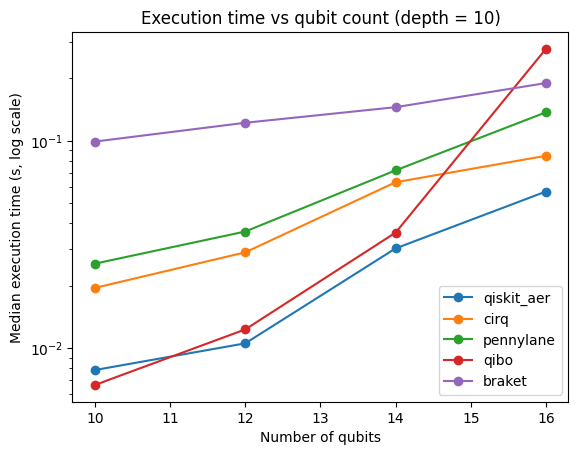

In [5]:
qubit_rows = [benchmark_point(n, 10) for n in [10, 12, 14, 16]]
print("  qubits  " + " ".join("%-11s" % n for n in simulators))
for row in qubit_rows:
    print("  %-7d " % row["qubits"] + " ".join("%9.4fs" % row[n] for n in simulators))

x = [row["qubits"] for row in qubit_rows]
for name in simulators:
    plt.plot(x, [row[name] for row in qubit_rows], marker="o", label=name)
plt.yscale("log")
plt.xlabel("Number of qubits")
plt.ylabel("Median execution time (s, log scale)")
plt.title("Execution time vs qubit count (depth = 10)")
plt.legend()
plt.show()

## Results: scaling with circuit depth (qubits = 12)

  depth   qiskit_aer  cirq        pennylane   qibo        braket     
  5          0.0070s    0.0164s    0.0192s    0.0068s    0.1080s
  10         0.0131s    0.0294s    0.0386s    0.0125s    0.1257s
  20         0.0227s    0.0547s    0.0722s    0.0245s    0.2626s
  40         0.0445s    0.1026s    0.1409s    0.0499s    0.6529s


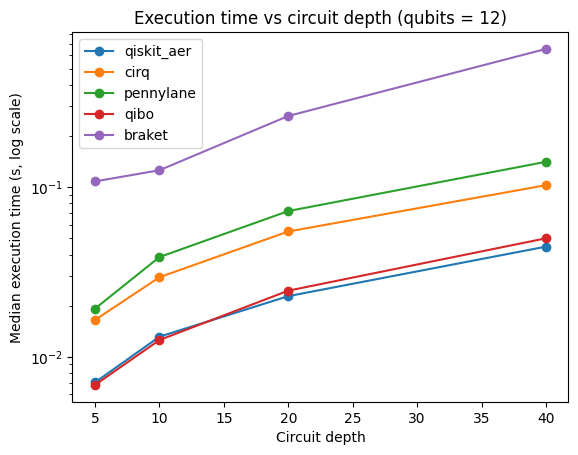

In [6]:
depth_rows = [benchmark_point(12, d) for d in [5, 10, 20, 40]]
print("  depth   " + " ".join("%-11s" % n for n in simulators))
for row in depth_rows:
    print("  %-7d " % row["depth"] + " ".join("%9.4fs" % row[n] for n in simulators))

x = [row["depth"] for row in depth_rows]
for name in simulators:
    plt.plot(x, [row[name] for row in depth_rows], marker="o", label=name)
plt.yscale("log")
plt.xlabel("Circuit depth")
plt.ylabel("Median execution time (s, log scale)")
plt.title("Execution time vs circuit depth (qubits = 12)")
plt.legend()
plt.show()

## What the numbers tell us

- **No simulator wins everywhere.** Qibo's NumPy backend is fastest at 10 qubits but slowest at 16; Qiskit Aer scales the best. Measure your own problem.
- **Constant overhead matters at small sizes.** Braket's `LocalSimulator` is dominated by a fixed per-run cost and changes the least as qubits grow.
- **Depth is cheaper than width.** Time grows *linearly* with depth but *exponentially* with qubits, matching $O(g \cdot 2^n)$. A deep narrow circuit simulates faster than a shallow wide one.

## References

[1] [UCC](https://github.com/unitaryfoundation/ucc) and [ucc-bench](https://github.com/unitaryfoundation/ucc-bench), Unitary Foundation.

[2] Javadi-Abhari, A., et al. (2024). Quantum computing with Qiskit. arXiv:2405.08810.

[3] Bergholm, V., et al. (2018). PennyLane. arXiv:1811.04968.

[4] Efthymiou, S., et al. (2021). Qibo. Quantum Science and Technology, 7(1), 015018.